Đang xử lý nâng cao với Scanpath Alignment trên 100 ảnh...
Đang tính toán độ tương đồng chuỗi DNA mắt (sẽ mất chút thời gian)...
Đang chạy Spectral Clustering trên ma trận Fusion...

--- KẾT QUẢ SCANPATH ALIGNMENT + FUSION ---
              precision    recall  f1-score   support

           0       0.70      0.62      0.66        80
           1       0.66      0.74      0.70        80

    accuracy                           0.68       160
   macro avg       0.68      0.68      0.68       160
weighted avg       0.68      0.68      0.68       160

Confusion Matrix:
[[50 30]
 [21 59]]


c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


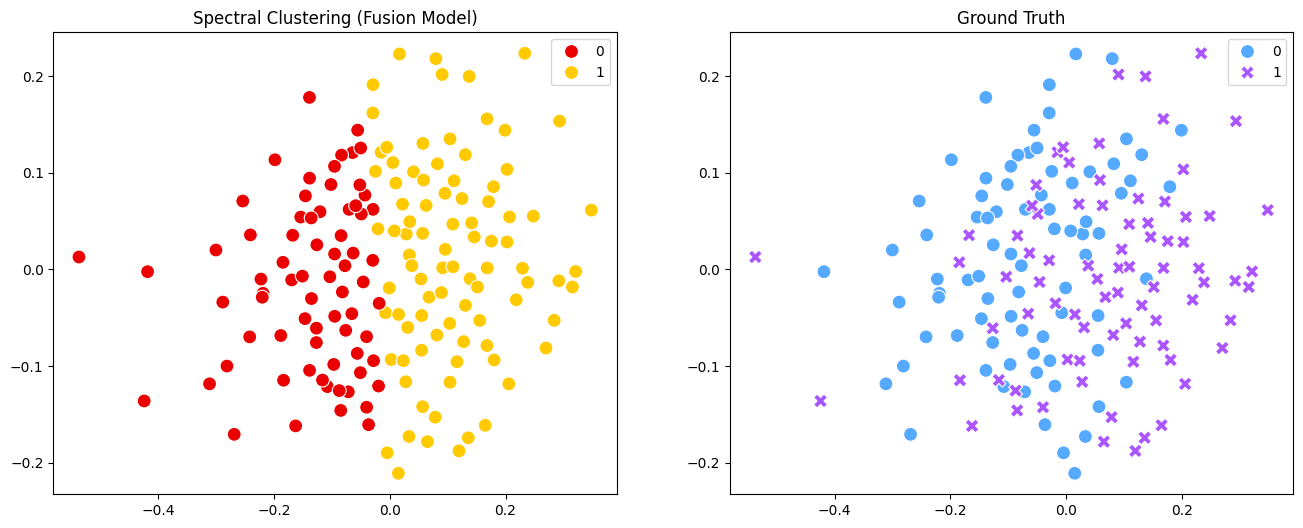

In [ ]:
import pandas as pd# đây là file bi over fitting
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, pairwise_distances,accuracy_score
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull, QhullError
import difflib # Thư viện chuẩn để so sánh chuỗi

# 1. Đọc dữ liệu
file_path = 'D:\\Code_File\\DAV\\final project\\original_file.csv'
df = pd.read_csv(file_path)

# --- HÀM TẠO CHUỖI SCANPATH (DNA CỦA MẮT) ---
def generate_scanpath_string(user_data, cluster_centers):
    if len(user_data) < 2: return ""
    
    # Dự đoán vùng nhìn (0, 1, 2, 3, 4)
    rois = cluster_centers.predict(user_data[['FIX_X', 'FIX_Y']])
    
    # Chuyển thành chuỗi ký tự (0->'A', 1->'B'...)
    # Nén chuỗi: Nếu nhìn liên tiếp A-A-A thì chỉ giữ lại 1 chữ A (quan tâm thứ tự, không quan tâm thời gian)
    compressed_path = []
    if len(rois) > 0:
        compressed_path.append(chr(65 + rois[0])) # 65 là mã ASCII của 'A'
        for i in range(1, len(rois)):
            char = chr(65 + rois[i])
            if char != compressed_path[-1]: # Chỉ thêm nếu khác ký tự trước đó
                compressed_path.append(char)
                
    return "".join(compressed_path)

# --- HÀM TÍNH ĐẶC TRƯNG VẬT LÝ (GIỮ LẠI CÁI TỐT NHẤT TỪ BƯỚC TRƯỚC) ---
def calculate_physical_features(user_data):
    points = user_data[['FIX_X', 'FIX_Y']].values
    if len(points) < 3: return [0, 0]
    
    # 1. Path Length (Quan trọng nhất)
    diffs = np.diff(points, axis=0)
    path_len = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
    
    # 2. Hull Area (Quan trọng nhì)
    try:
        hull = ConvexHull(points)
        hull_area = hull.volume
    except:
        hull_area = 0
        
    return [path_len, hull_area]

# --- MAIN LOOP ---
patient_features = {} # Lưu đặc trưng vật lý
patient_sequences = {} # Lưu chuỗi scanpath (list các chuỗi của các ảnh)
unique_images = df['image_id'].unique()
print(f"Đang xử lý nâng cao với Scanpath Alignment trên {len(unique_images)} ảnh...")

for img_id in unique_images:
    img_data = df[df['image_id'] == img_id].copy()
    if len(img_data) < 50: continue
    
    # Tạo ROI động
    kmeans_roi = KMeans(n_clusters=5, random_state=42, n_init=10)
    kmeans_roi.fit(img_data[['FIX_X', 'FIX_Y']])
    
    for pid, group in img_data.groupby('numeric_id'):
        # 1. Lấy Sequence
        seq = generate_scanpath_string(group, kmeans_roi)
        if pid not in patient_sequences: patient_sequences[pid] = []
        if seq: patient_sequences[pid].append(seq)
            
        # 2. Lấy Physical Features
        phys = calculate_physical_features(group)
        if pid not in patient_features: patient_features[pid] = []
        patient_features[pid].append(phys)

# --- TỔNG HỢP DỮ LIỆU ---
pids = []
X_phys = [] # Ma trận đặc trưng vật lý
X_seqs = [] # List các list chuỗi
labels = []

label_map = df.drop_duplicates('numeric_id').set_index('numeric_id')['label']

for pid in patient_features:
    if pid not in patient_sequences or not patient_features[pid]: continue
    
    # Trung bình đặc trưng vật lý
    avg_phys = np.mean(patient_features[pid], axis=0)
    X_phys.append(avg_phys)
    
    # Lưu lại tập các chuỗi của bệnh nhân này để so sánh sau
    # (Chỉ lấy tối đa 20 chuỗi đầu để tính toán cho nhanh nếu quá nhiều ảnh)
    X_seqs.append(patient_sequences[pid][:20])
    
    pids.append(pid)
    labels.append(label_map[pid])

X_phys = np.array(X_phys)
y_true = np.array(labels)
n_samples = len(y_true)

# --- BƯỚC QUAN TRỌNG: TẠO MA TRẬN TƯƠNG ĐỒNG (SIMILARITY MATRIX) ---

# 1. Similarity dựa trên Vật lý (PathLength, HullArea)
scaler = MinMaxScaler()
X_phys_norm = scaler.fit_transform(X_phys)
# Tính khoảng cách Euclidean
dist_phys = pairwise_distances(X_phys_norm, metric='euclidean')
# Chuyển thành độ tương đồng (Gaussian Kernel): Sim = exp(-gamma * dist^2)
sim_phys = np.exp(-1.0 * dist_phys ** 2)

# 2. Similarity dựa trên Sequence Alignment (Chuỗi hành vi)
print("Đang tính toán độ tương đồng chuỗi DNA mắt (sẽ mất chút thời gian)...")
sim_seq = np.zeros((n_samples, n_samples))

# Hàm so sánh 2 tập chuỗi của 2 người
def compare_user_sequences(seqs_A, seqs_B):
    # So sánh từng cặp chuỗi tương ứng của cùng 1 ảnh (giả sử thứ tự ảnh giống nhau)
    # Hoặc nếu ảnh khác nhau, ta so sánh ngẫu nhiên (để đơn giản ta lấy trung bình độ giống nhau)
    scores = []
    min_len = min(len(seqs_A), len(seqs_B))
    if min_len == 0: return 0
    
    for i in range(min_len):
        # SequenceMatcher trả về ratio [0, 1] về độ giống nhau
        s = difflib.SequenceMatcher(None, seqs_A[i], seqs_B[i]).ratio()
        scores.append(s)
    return np.mean(scores)

for i in range(n_samples):
    for j in range(i, n_samples):
        if i == j:
            sim_seq[i, j] = 1.0
        else:
            score = compare_user_sequences(X_seqs[i], X_seqs[j])
            sim_seq[i, j] = score
            sim_seq[j, i] = score # Ma trận đối xứng

# 3. KERNEL FUSION (Kết hợp 2 ma trận)
# Chúng ta tin vào cái nào hơn? 
# PathLength đang rất mạnh (0.27), nhưng Sequence sẽ sửa sai cho các ca khó.
# Thử tỷ lệ: 60% Vật lý + 40% Chuỗi
final_affinity = 0.6 * sim_phys + 0.4 * sim_seq

# --- SPECTRAL CLUSTERING TRÊN MA TRẬN KẾT HỢP ---
print("Đang chạy Spectral Clustering trên ma trận Fusion...")
spectral = SpectralClustering(n_clusters=2, affinity='precomputed', random_state=42)
preds = spectral.fit_predict(final_affinity)

# Đảo nhãn nếu cần
if accuracy_score(y_true, preds) < 0.5:
    preds = 1 - preds

# --- REPORT ---
print("\n--- KẾT QUẢ SCANPATH ALIGNMENT + FUSION ---")
print(classification_report(y_true, preds))
print("Confusion Matrix:")
print(confusion_matrix(y_true, preds))

# --- VISUALIZATION (Dùng MDS để vẽ ma trận khoảng cách) ---
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
# Chuyển Affinity thành Distance để vẽ (Dist = 1 - Sim)
distance_matrix = 1 - final_affinity
X_mds = mds.fit_transform(distance_matrix)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_mds[:,0], y=X_mds[:,1], hue=preds, palette='hot', s=100)
plt.title('Spectral Clustering (Fusion Model)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_mds[:,0], y=X_mds[:,1], hue=y_true, palette='cool', style=y_true, s=100)
plt.title('Ground Truth')
plt.show()